# Ring Attractor Model: *Drosophila* vs *Aedes*

Connectome-constrained rate model of the heading-direction circuit
(EPG ↔ Δ7).

**Model**: τ · dr/dt = −r + φ(W·r + I_ext), 
(EPG = excitatory, Δ7 = inhibitory).

**Data**: Synapse-level connectivity from MCNS (Drosophila) and
Aedes, stored in `connectome_data.pkl`.

**Pipeline**:
1. Load connectome → 2. Visualise connectivity → 3. Baseline kymographs → 4. Stability sweep


In [1]:
import importlib
import matplotlib.pyplot as plt
import numpy as np

# Deep-reload all cx_model submodules
import cx_model
for submod in ['activation', 'data_loader', 'weights',
               'simulation', 'analysis', 'visualization']:
    importlib.reload(getattr(cx_model, submod))
importlib.reload(cx_model)

from cx_model import (
    load_connectome, get_species_data, EB_RING_ORDER,
    build_weight_matrix, find_epg_indices, extract_4blocks,
    simulate_ring_attractor, make_stimulus_func,
    run_stability_sweep,
    plot_block_heatmaps, plot_kymograph_pair,
    plot_epg_profiles, plot_stability_grid,
    plot_full_sweep_grid,
)

plt.rcParams['figure.dpi'] = 100
print('All imports loaded (with reload).')


All imports loaded (with reload).


## 1. Configuration

All tuneable parameters. Edit this cell and re-run the notebook.


In [2]:
# ═══════════════════════════════════════════════════════════════
# SIMULATION PARAMETERS
# ═══════════════════════════════════════════════════════════════

CONFIG = dict(
    # ── Network gains ──────────────────────────────────────────
    gain_epg_fly   = 20.0,    # EPG gain (Drosophila)
    gain_d7_fly    = 20.0,    # Δ7  gain (Drosophila)
    gain_epg_aedes = 30.0,    # EPG gain (Aedes)
    gain_d7_aedes  = 10.0,    # Δ7  gain (Aedes)

    # ── Neuron model ───────────────────────────────────────────
    r_max       = 200.0,      # max firing rate (Hz)
    theta       = 0,          # activation threshold
    tau         = 0.05,       # membrane time constant (s)
    noise       = 0,          # Gaussian noise σ (0 = deterministic)
    syn_thresh  = 4,          # min raw synapse count to keep

    # ── Timing ─────────────────────────────────────────────────
    T           = 8.,         # total simulation time (s)
    dt          = 0.01,       # Euler time step (s)

    # ── Stimulus 1 (initial bump) ──────────────────────────────
    stim1_pbs   = ['L4'],     # PB glomerulus to activate
    stim1_t     = (0.5, 1.0), # onset / offset (s)
    stim1_amp   = 100.0,      # amplitude (Hz)

    # ── Stimulus 2 (perturbation for part) ──────────────────────────────
    stim2_pbs   = ['L1'],     # PB glomerulus to perturb
    stim2_t     = (4.0, 4.4), # onset / offset (s)
    stim2_amp   = 100.0,      # amplitude (Hz)
)

# Print for verification
print('Simulation configuration:')
for k, v in CONFIG.items():
    print(f'  {k:18s} = {v}')


Simulation configuration:
  gain_epg_fly       = 20.0
  gain_d7_fly        = 20.0
  gain_epg_aedes     = 30.0
  gain_d7_aedes      = 10.0
  r_max              = 200.0
  theta              = 0
  tau                = 0.05
  noise              = 0
  syn_thresh         = 4
  T                  = 8.0
  dt                 = 0.01
  stim1_pbs          = ['L4']
  stim1_t            = (0.5, 1.0)
  stim1_amp          = 100.0
  stim2_pbs          = ['L1']
  stim2_t            = (4.0, 4.4)
  stim2_amp          = 100.0


## 2. Load & Inspect Connectome

Load EPG–Δ7 connectivity from the preprocessed pickle file.
Connections below `syn_thresh` are removed and the matrix is
renormalised.


In [3]:
# Load connectome with synapse-count threshold
data = load_connectome('data/connectome_data.pkl',
                       syn_threshold=CONFIG['syn_thresh'])

fly_sp   = get_species_data(data, 'fly')
aedes_sp = get_species_data(data, 'aedes')

n_fly  = sum(1 for v in fly_sp['id_to_type'].values() if v == 'EPG')
n_aed  = sum(1 for v in aedes_sp['id_to_type'].values() if v == 'EPG')
print(f'Fly EPGs:   {n_fly}')
print(f'Aedes EPGs: {n_aed}')


  fly: syn >= 4 → 4708 → 3675 connections (1033 removed, 21.9%), mean_all=7.81
  aedes: syn >= 4 → 2797 → 1425 connections (1372 removed, 49.1%), mean_all=2.06
Fly EPGs:   46
Aedes EPGs: 45


### Connectivity Comparison: Raw → Global Fraction → Global Fraction Filtered

Three views of the 4-block (E→E, E→I, I→E, I→I) connectivity per species:

| Column | Description |
|--------|-------------|
| **Raw** | Integer synapse counts (no normalisation) |
| **Global Fraction** | `raw[i,j] / total_output_j` across the whole connectome |
| **Global Fraction Filtered** | Global fraction with weak connections (raw < threshold) zeroed |

The **Global Fraction Filtered** matrix is used for all downstream simulations.


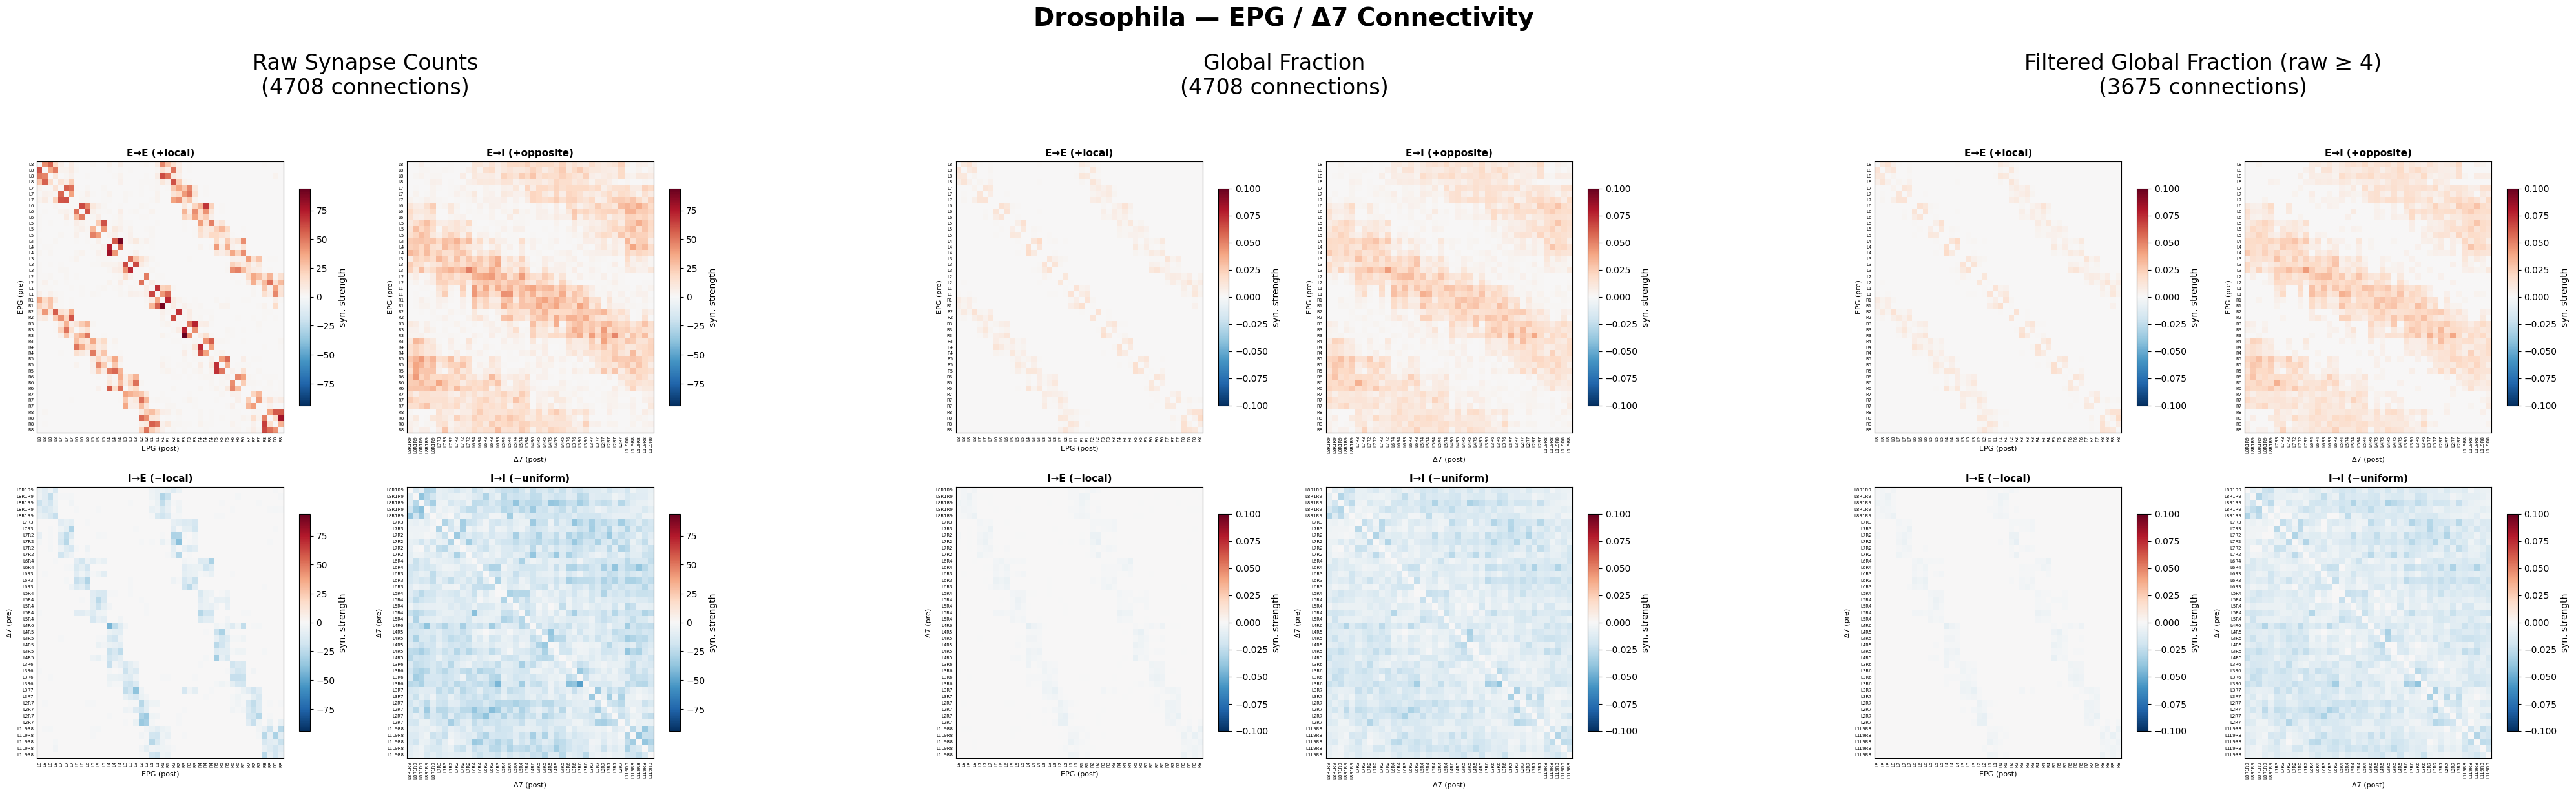

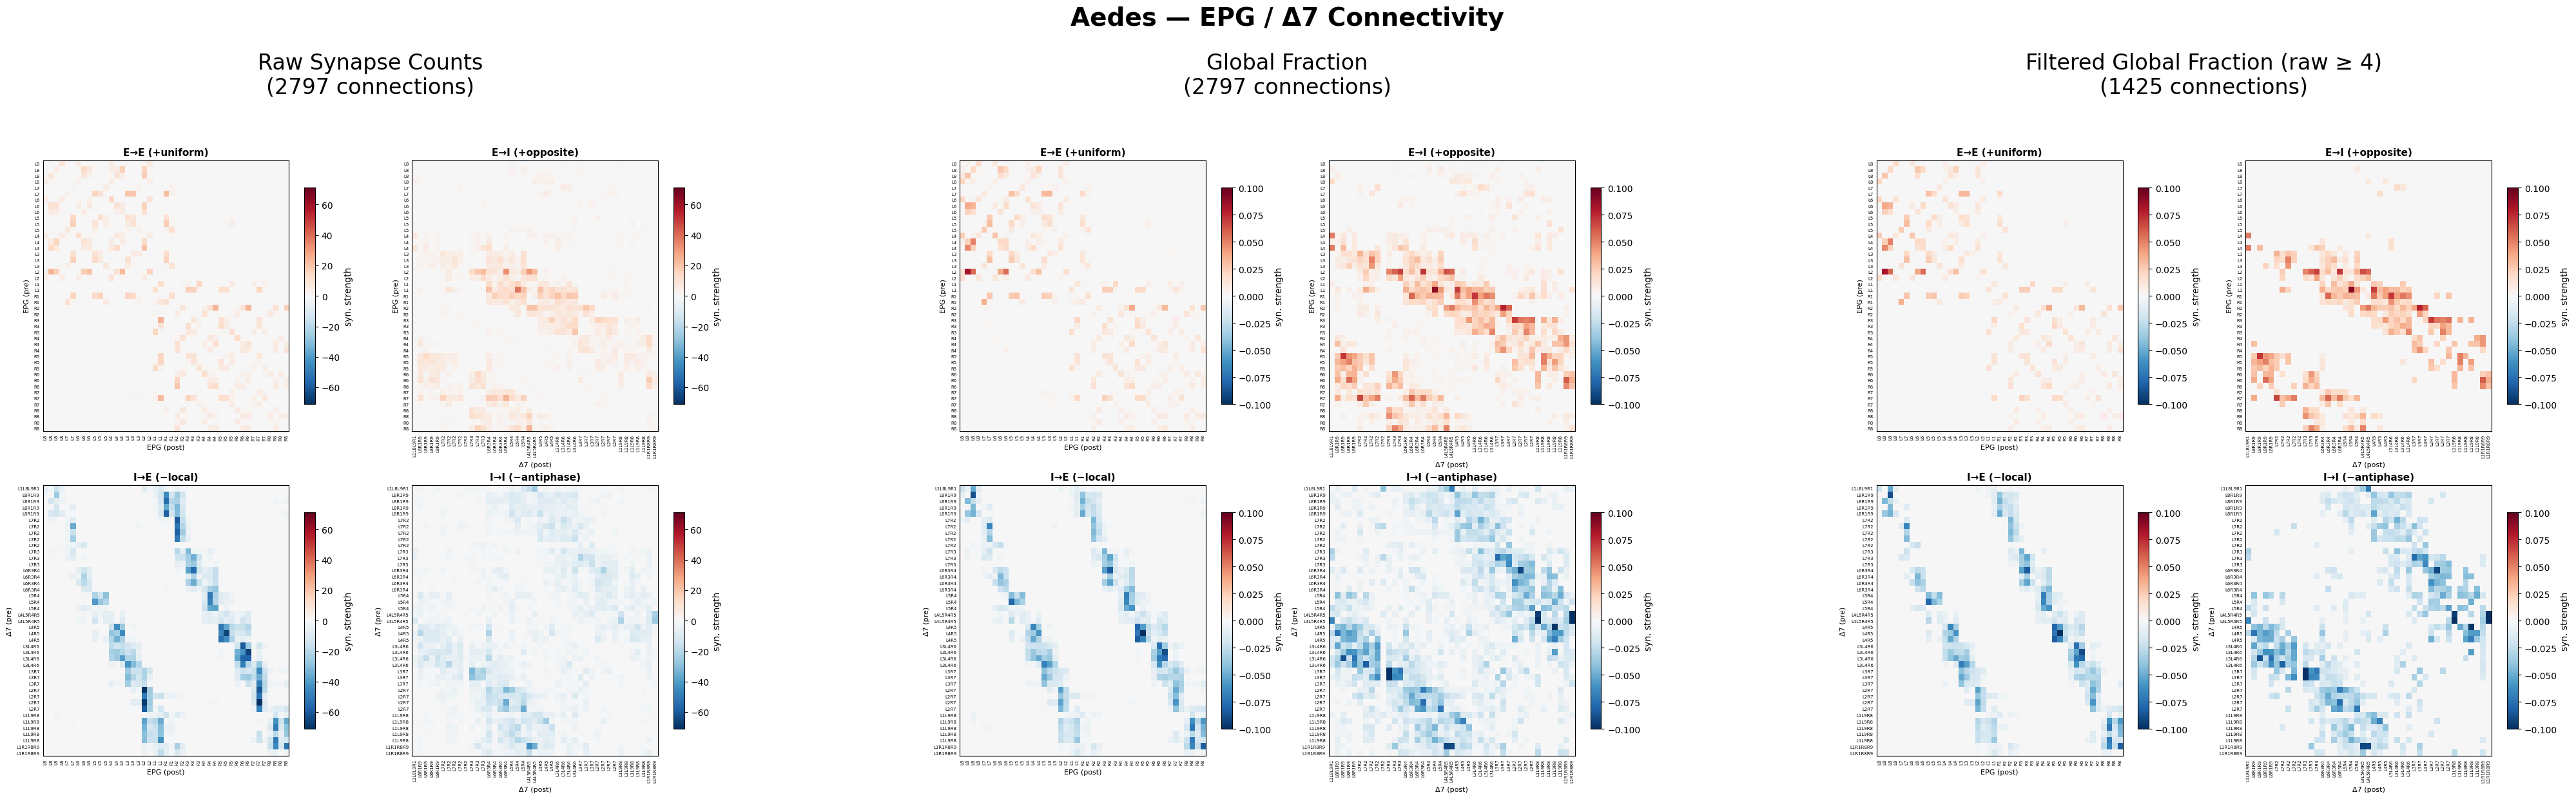

★ Simulation matrices set to: Filtered Global Fraction (raw ≥ 4)


In [4]:
# Side-by-side: Raw | Global Fraction | Filtered (per species)
import pickle
SYN_FILTER = CONFIG['syn_thresh']

with open('data/connectome_data.pkl', 'rb') as f:
    _d_orig = pickle.load(f)

block_names = ['E→E', 'E→I', 'I→E', 'I→I']
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]
sign_map = {'E→E': +1, 'E→I': +1, 'I→E': -1, 'I→I': -1}
type_map = {
    'E→E': ('EPG (pre)', 'EPG (post)'),
    'E→I': ('EPG (pre)', 'Δ7 (post)'),
    'I→E': ('Δ7 (pre)', 'EPG (post)'),
    'I→I': ('Δ7 (pre)', 'Δ7 (post)'),
}

for species, sp, blabels in [
    ('Drosophila', fly_sp,
     ['E→E (+local)', 'E→I (+opposite)', 'I→E (−local)', 'I→I (−uniform)']),
    ('Aedes', aedes_sp,
     ['E→E (+uniform)', 'E→I (+opposite)', 'I→E (−local)', 'I→I (−antiphase)']),
]:
    key = 'fly' if species == 'Drosophila' else 'aedes'
    raw_mat = _d_orig[f'matrix_{key}']
    glob_norm = _d_orig[f'matrix_norm_{key}']
    filt_norm = _d_orig[f'matrix_norm_{key}'].copy()
    filt_norm.values[raw_mat.values < SYN_FILTER] = 0

    # Prepare 3 cases
    cases = [
        ('Raw Synapse Counts', raw_mat, None),
        ('Global Fraction', glob_norm, 0.1),
        (f'Filtered Global Fraction (raw ≥ {SYN_FILTER})', filt_norm, 0.1),
    ]

    # One wide figure with 3 subfigures
    fig = plt.figure(figsize=(42, 12))
    subfigs = fig.subfigures(1, 3, wspace=0.05)

    for sf, (case_name, mat, vmax_set) in zip(subfigs, cases):
        blocks, rl, cl = extract_4blocks(
            mat, sp['sorted_ids_pb'],
            sp['id_to_type'], sp['id_to_pb'],
            i_order=sp['delta7_order'],
        )

        # Sign and compute vmax
        signed = {}
        for b in block_names:
            vals = blocks[b].values if hasattr(blocks[b], 'values') else blocks[b]
            signed[b] = vals * sign_map[b]
        if vmax_set is None:
            vmax = max(np.abs(signed[b]).max() for b in block_names) or 0.01
        else:
            vmax = vmax_set

        axes = sf.subplots(2, 2)
        for bname, (r, c), label in zip(block_names, positions, blabels):
            ax = axes[r, c]
            im = ax.imshow(signed[bname], aspect='auto', cmap='RdBu_r',
                           vmin=-vmax, vmax=vmax, interpolation='none')
            ax.set_title(label, fontsize=11, fontweight='bold')
            rl_b, cl_b = rl[bname], cl[bname]
            ax.set_yticks(range(len(rl_b)))
            ax.set_yticklabels(rl_b, fontsize=5)
            ax.set_xticks(range(len(cl_b)))
            ax.set_xticklabels(cl_b, fontsize=5, rotation=90)
            ax.set_ylabel(type_map[bname][0], fontsize=8)
            ax.set_xlabel(type_map[bname][1], fontsize=8)
            ax.grid(False)
            ax.tick_params(length=0)
            sf.colorbar(im, ax=ax, label='syn. strength', shrink=0.8)

        nz = sum((np.abs(signed[b]) > 0).sum() for b in block_names)
        sf.suptitle(f'{case_name}\n({nz} connections)',
                    fontsize=24, y=1.02)

    fig.suptitle(f'{species} — EPG / Δ7 Connectivity',
                 fontsize=28, fontweight='bold', y=1.08)
    plt.show()

# ★ Save filtered matrix for simulation
for sp, key in [(fly_sp, 'fly'), (aedes_sp, 'aedes')]:
    filt = _d_orig[f'matrix_norm_{key}'].copy()
    filt.values[_d_orig[f'matrix_{key}'].values < SYN_FILTER] = 0
    sp['matrix_norm'] = filt

del _d_orig
print(f'★ Simulation matrices set to: Filtered Global Fraction (raw ≥ {SYN_FILTER})')


In [5]:
# Build weight matrices with per-type gains: (gain_EPG, gain_Δ7)
W_fly, uids_fly, N_E_fly, tr_fly = build_weight_matrix(
    fly_sp['matrix_norm'], fly_sp['sorted_ids_eb'],
    fly_sp['id_to_type'], fly_sp['id_to_pb'],
    (CONFIG['gain_epg_fly'], CONFIG['gain_d7_fly']),
    fly_sp['delta7_order'],
)
W_aedes, uids_aedes, N_E_aedes, tr_aedes = build_weight_matrix(
    aedes_sp['matrix_norm'], aedes_sp['sorted_ids_eb'],
    aedes_sp['id_to_type'], aedes_sp['id_to_pb'],
    (CONFIG['gain_epg_aedes'], CONFIG['gain_d7_aedes']),
    aedes_sp['delta7_order'],
)

# EPG PB labels (for y-axis annotation)
epg_labels_fly   = [fly_sp['id_to_pb'].get(uids_fly[i], '?')
                    for i in range(N_E_fly)]
epg_labels_aedes = [aedes_sp['id_to_pb'].get(uids_aedes[i], '?')
                    for i in range(N_E_aedes)]

# Shared simulation kwargs
phi_kw = {'theta': CONFIG['theta'], 'r_max': CONFIG['r_max']}
tau_d  = {'EPG': CONFIG['tau'], 'Delta7': CONFIG['tau']}

print(f'W_fly   : {W_fly.shape}  range [{W_fly.min():.2f}, {W_fly.max():.2f}]')
print(f'W_aedes : {W_aedes.shape}  range [{W_aedes.min():.2f}, {W_aedes.max():.2f}]')


W_fly   : (88, 88)  range [-0.81, 0.85]
W_aedes : (88, 88)  range [-2.99, 2.47]


## 3. Stability Sweep

Test bump persistence and perturbation response.

- **Baseline** (row 0): Stim1 only at each EPG subtype → does the bump persist?
- **Rows 1–16**: Stim1 + 2nd stimulus at each of EPG subtype → does the bump shift?

Green ▶ = stim1 neurons, cyan ◆ = stim2 neurons.


In [6]:
# Stability sweep: baseline + 16 perturbation conditions
config_fly   = {**CONFIG, 'gain': (CONFIG['gain_epg_fly'],   CONFIG['gain_d7_fly'])}
config_aedes = {**CONFIG, 'gain': (CONFIG['gain_epg_aedes'], CONFIG['gain_d7_aedes'])}

sweep_fly,  kymo_fly  = run_stability_sweep(
    W_fly,  len(uids_fly),  N_E_fly,  tr_fly,
    uids_fly,  fly_sp['id_to_type'],  fly_sp['id_to_pb'],
    config_fly,  EB_RING_ORDER,
)
sweep_aedes, kymo_aedes = run_stability_sweep(
    W_aedes, len(uids_aedes), N_E_aedes, tr_aedes,
    uids_aedes, aedes_sp['id_to_type'], aedes_sp['id_to_pb'],
    config_aedes, EB_RING_ORDER,
)

# Build stim-index maps for the stability grid plot
stim_indices = {
    'fly':   {'s1': find_epg_indices(uids_fly,   fly_sp['id_to_type'],
                                     fly_sp['id_to_pb'],   N_E_fly,
                                     CONFIG['stim1_pbs'])},
    'aedes': {'s1': find_epg_indices(uids_aedes, aedes_sp['id_to_type'],
                                     aedes_sp['id_to_pb'], N_E_aedes,
                                     CONFIG['stim1_pbs'])},
}
stim2_map_fly   = {g: find_epg_indices(uids_fly,   fly_sp['id_to_type'],
                                        fly_sp['id_to_pb'],   N_E_fly,   [g])
                   for g in EB_RING_ORDER}
stim2_map_aedes = {g: find_epg_indices(uids_aedes, aedes_sp['id_to_type'],
                                        aedes_sp['id_to_pb'], N_E_aedes, [g])
                   for g in EB_RING_ORDER}

print('Stability sweep complete.')


Stability sweep complete.


### Baseline Kymographs: Each PB Glomerulus

Activate each of EPG subtype one at a time (no perturbation).
Shows whether the network can form and sustain a heading bump at every position.


  L7 done (25%)


  L5 done (50%)


  L3 done (75%)


  L1 done (100%)


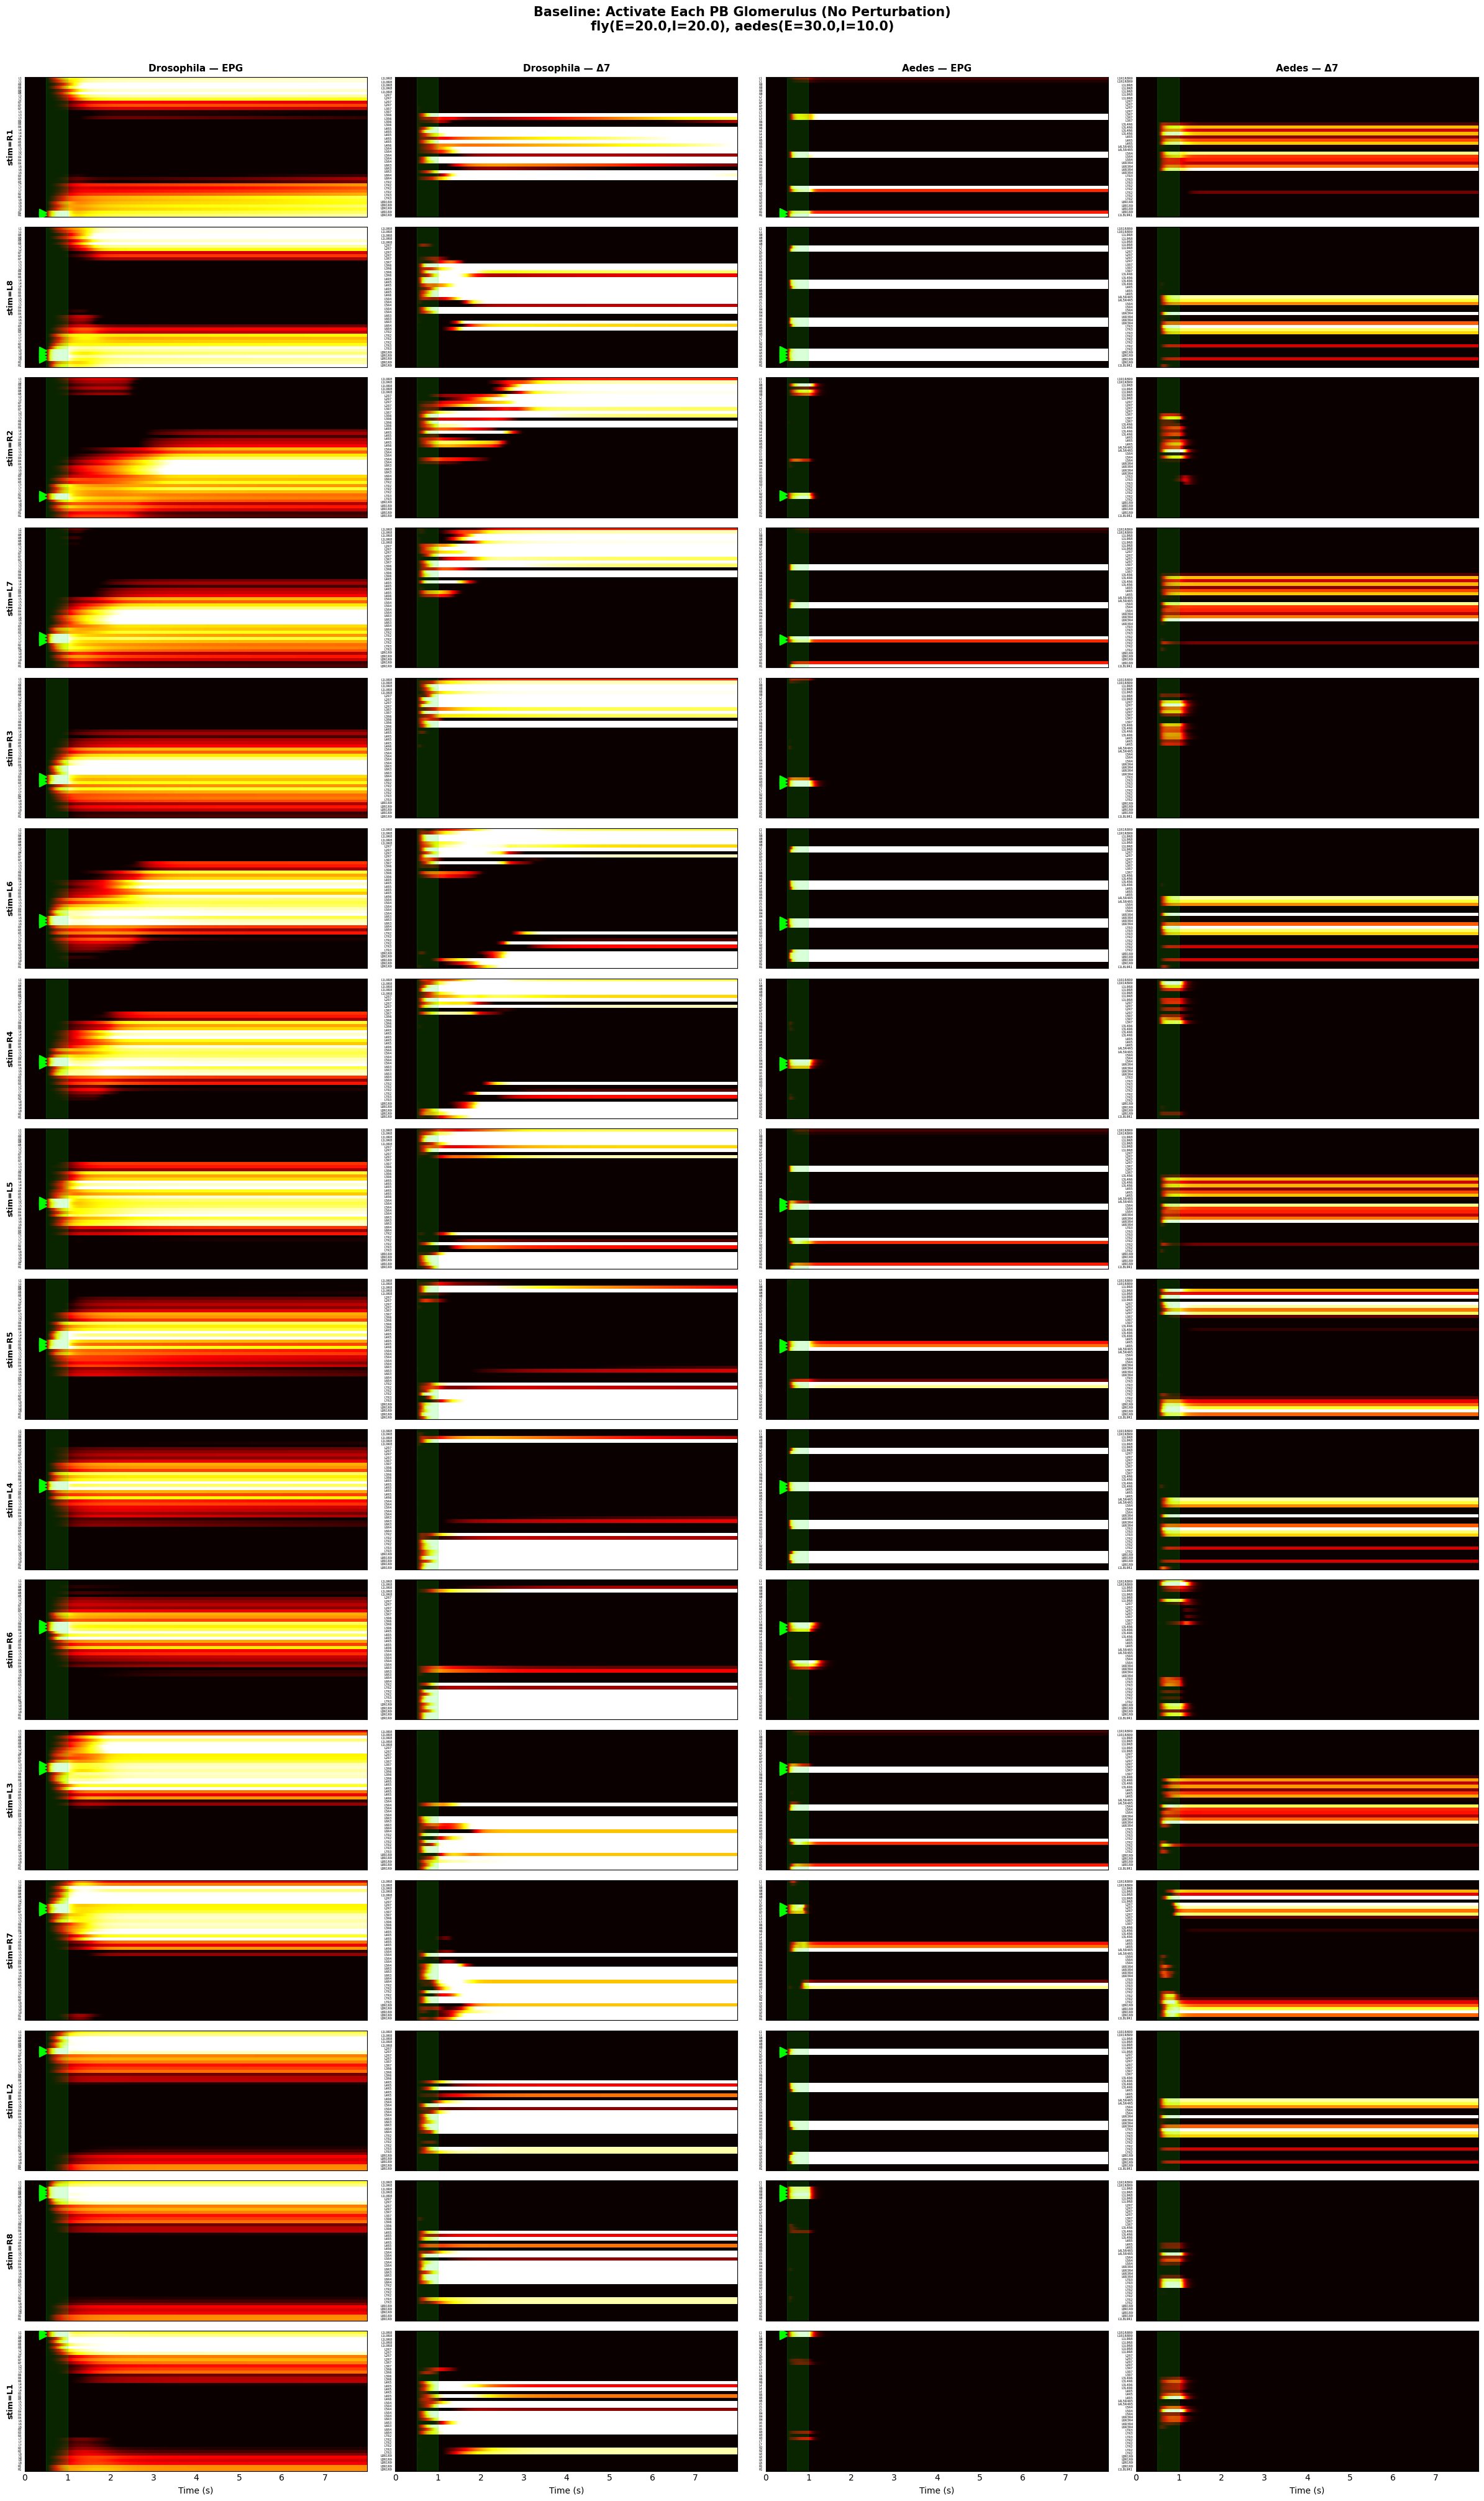

Baseline complete.


In [7]:
# Baseline: activate each EPG subtype, no perturbation
# 16 rows (one per PB glomerulus) × 4 cols (Fly EPG, Fly Δ7, Aedes EPG, Aedes Δ7)

n_glom = len(EB_RING_ORDER)
fig, axes = plt.subplots(n_glom, 4, figsize=(24, n_glom * 2.5),
                         sharex=True)

species_info = [
    ('Drosophila', W_fly, len(uids_fly), N_E_fly, tr_fly,
     uids_fly, fly_sp,
     (CONFIG['gain_epg_fly'], CONFIG['gain_d7_fly'])),
    ('Aedes', W_aedes, len(uids_aedes), N_E_aedes, tr_aedes,
     uids_aedes, aedes_sp,
     (CONFIG['gain_epg_aedes'], CONFIG['gain_d7_aedes'])),
]

for row, s1_pb in enumerate(EB_RING_ORDER):
    for sp_idx, (name, W, N_tot, N_E, tr, uids, sp, gain) in enumerate(species_info):

        s1_idx = find_epg_indices(uids, sp['id_to_type'], sp['id_to_pb'],
                                  N_E, [s1_pb])
        stim = make_stimulus_func([
            {'indices': s1_idx, 't_on': CONFIG['stim1_t'][0],
             't_off': CONFIG['stim1_t'][1], 'amplitude': CONFIG['stim1_amp']},
        ], N_tot)

        t, r = simulate_ring_attractor(
            W, N_tot, tr, tau_d, stim,
            T=CONFIG['T'], dt=CONFIG['dt'],
            phi_kwargs=phi_kw, noise_sigma=CONFIG['noise'],
        )

        N_I = N_tot - N_E

        # EPG kymograph
        ax_e = axes[row, sp_idx * 2]
        ax_e.imshow(r[:, :N_E].T, aspect='auto', origin='lower',
                    extent=[t[0], t[-1], 0, N_E],
                    cmap='hot', interpolation='none')
        ax_e.axvspan(*CONFIG['stim1_t'], color='lime', alpha=0.15)
        for idx in s1_idx:
            t_off = (t[-1] - t[0]) * 0.01
            ax_e.plot(CONFIG['stim1_t'][0] - t_off, idx + 0.5,
                      '>', color='lime', ms=8, zorder=10)

        # Δ7 kymograph
        ax_d = axes[row, sp_idx * 2 + 1]
        ax_d.imshow(r[:, N_E:].T, aspect='auto', origin='lower',
                    extent=[t[0], t[-1], 0, N_I],
                    cmap='hot', interpolation='none')
        ax_d.axvspan(*CONFIG['stim1_t'], color='lime', alpha=0.15)

        for ax in [ax_e, ax_d]:
            ax.grid(False)
            ax.tick_params(length=0)

        # Y-axis labels (left-most column only)
        if sp_idx == 0:
            epg_labs = [sp['id_to_pb'].get(uids[i], '?') for i in range(N_E)]
            ax_e.set_yticks(np.arange(N_E) + 0.5)
            ax_e.set_yticklabels(epg_labs, fontsize=3.5)
            ax_e.set_ylabel(f'stim={s1_pb}', fontsize=9, fontweight='bold')

            d7_labs = [sp['id_to_pb'].get(uids[N_E + i], '?') for i in range(N_I)]
            ax_d.set_yticks(np.arange(N_I) + 0.5)
            ax_d.set_yticklabels(d7_labs, fontsize=3.5)
        else:
            # Aedes EPG y-axis labels
            epg_labs_a = [sp['id_to_pb'].get(uids[i], '?') for i in range(N_E)]
            ax_e.set_yticks(np.arange(N_E) + 0.5)
            ax_e.set_yticklabels(epg_labs_a, fontsize=3.5)
            # Aedes Δ7 y-axis labels
            d7_labs = [sp['id_to_pb'].get(uids[N_E + i], '?') for i in range(N_I)]
            ax_d.set_yticks(np.arange(N_I) + 0.5)
            ax_d.set_yticklabels(d7_labs, fontsize=3.5)

        # Column titles (first row)
        if row == 0:
            ax_e.set_title(f'{name} — EPG', fontsize=11, fontweight='bold')
            ax_d.set_title(f'{name} — Δ7', fontsize=11, fontweight='bold')

        # X-axis (last row)
        if row == n_glom - 1:
            ax_e.set_xlabel('Time (s)')
            ax_d.set_xlabel('Time (s)')

    if (row + 1) % 4 == 0:
        print(f'  {s1_pb} done ({(row+1)/n_glom*100:.0f}%)')

fig.suptitle(
    f'Baseline: Activate Each PB Glomerulus (No Perturbation)\n'
    f'fly(E={CONFIG["gain_epg_fly"]},I={CONFIG["gain_d7_fly"]}), '
    f'aedes(E={CONFIG["gain_epg_aedes"]},I={CONFIG["gain_d7_aedes"]})',
    fontsize=15, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()
print('Baseline complete.')


### Stability Test: Stim1 + Perturbation Kymographs

17 rows of EPG kymographs (time × neuron) for each species:

- **Row 0 (baseline)**: Stim1 only — does the bump form and persist?
- **Rows 1–16**: Stim1 + a 2nd stimulus at each EPG subtype — does the bump shift?

Markers: green **▶** = stim1 neurons, cyan **◆** = stim2 neurons.
Shaded bands mark the stimulus windows (green = stim1, cyan = stim2).


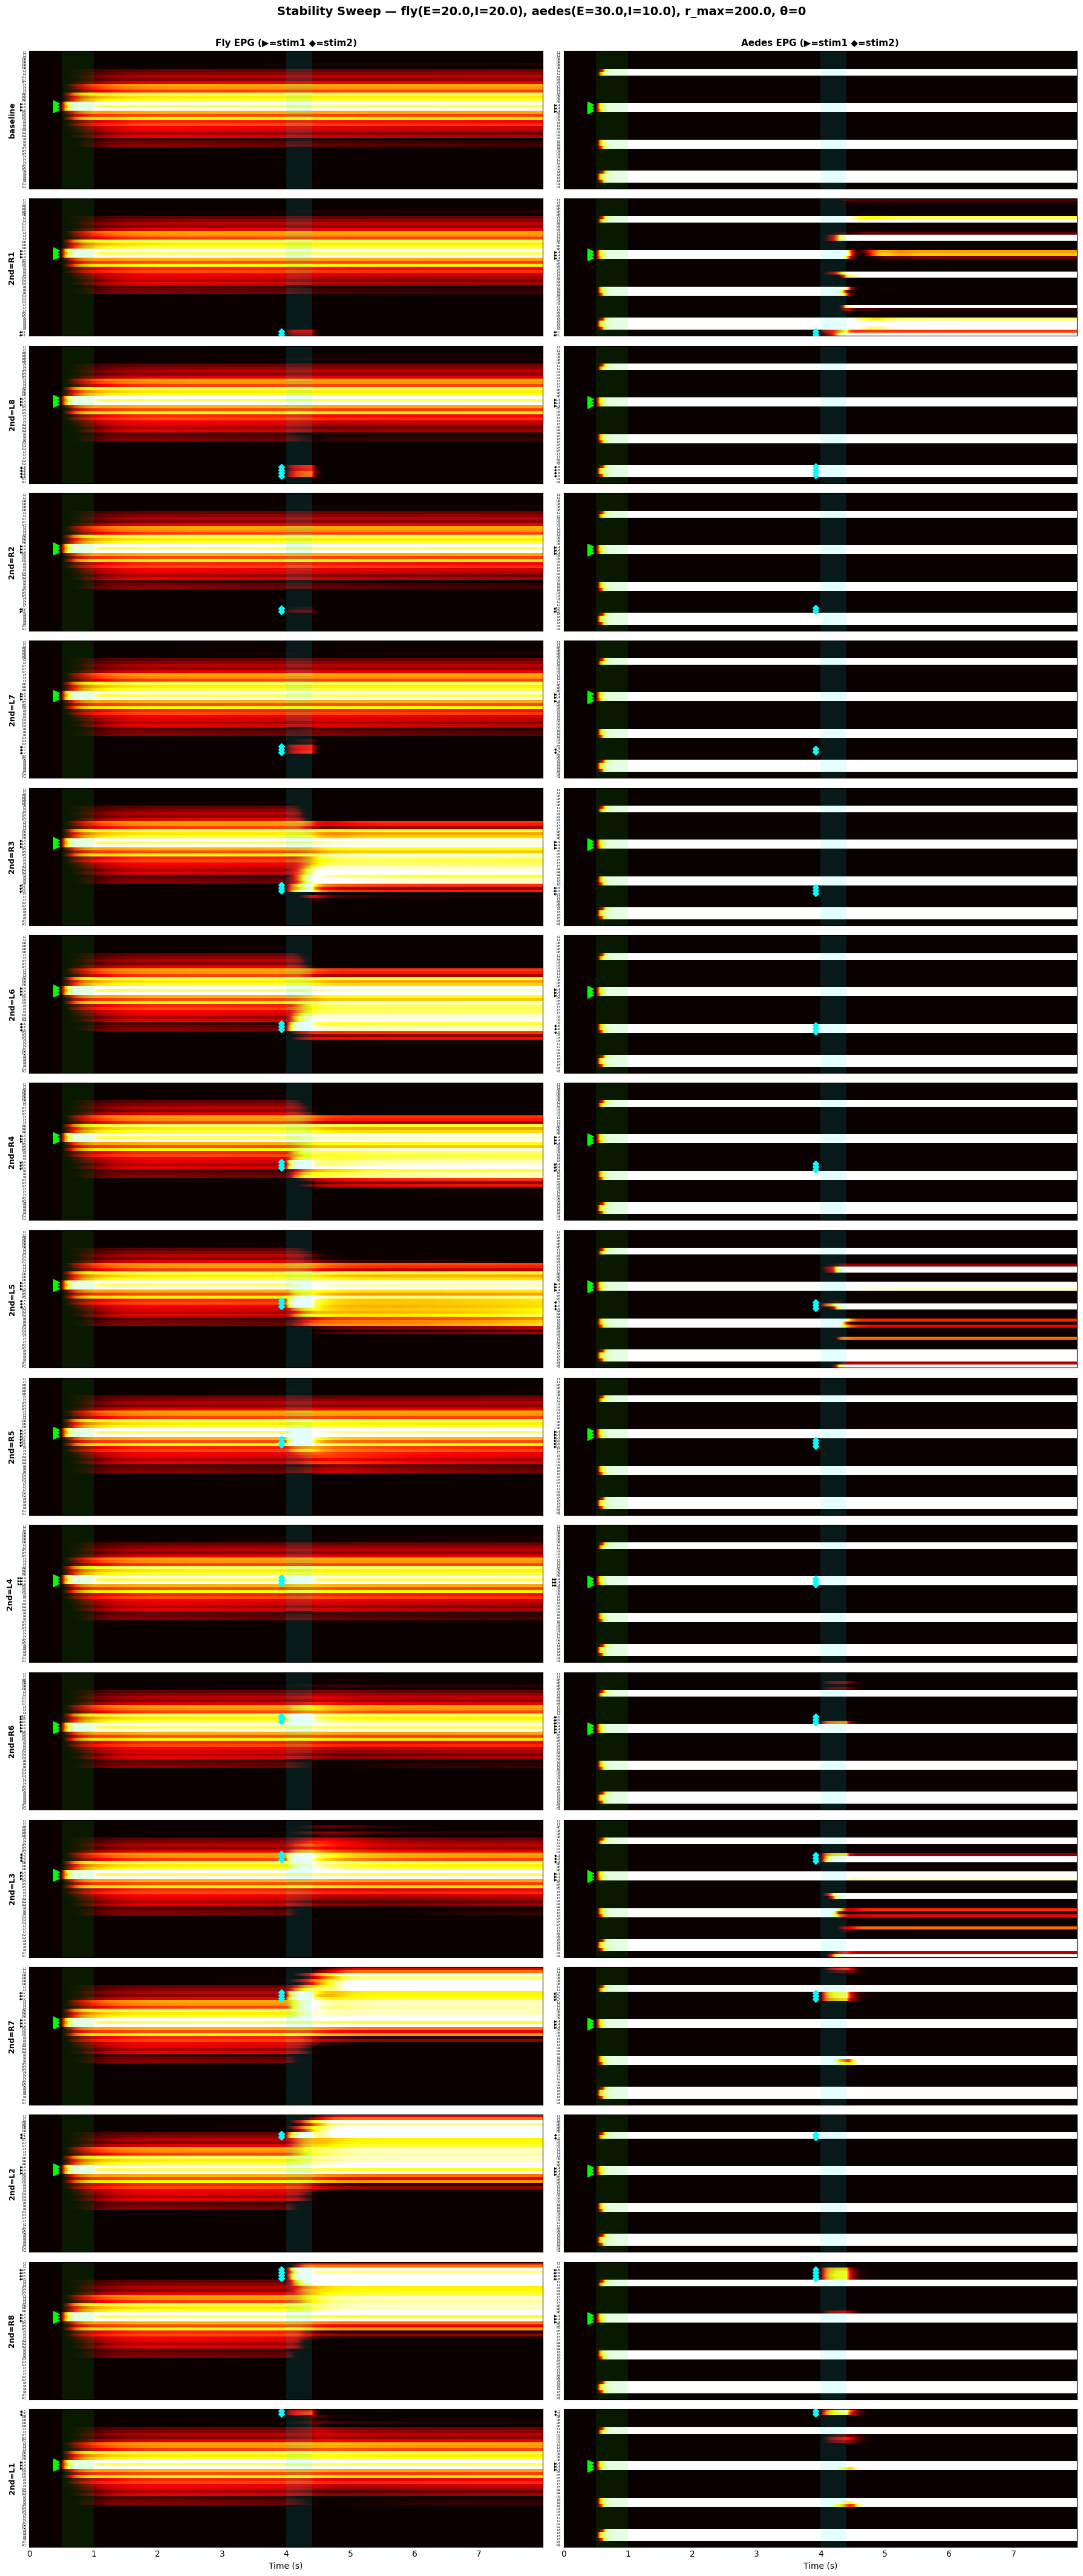

In [8]:
# Plot stability sweep kymographs (▶=stim1, ◆=stim2)
plot_stability_grid(kymo_fly, kymo_aedes, CONFIG,
                    EB_RING_ORDER, N_E_fly, N_E_aedes,
                    epg_labels_fly=epg_labels_fly,
                    epg_labels_aedes=epg_labels_aedes,
                    stim1_idx_fly=stim_indices['fly']['s1'],
                    stim1_idx_aedes=stim_indices['aedes']['s1'],
                    stim2_idx_map_fly=stim2_map_fly,
                    stim2_idx_map_aedes=stim2_map_aedes)
plt.show()


## 4. Bump Shift Analysis

EPG firing rates at T=end for each perturbation condition.
**Black** = baseline (no 2nd stim), **coloured** = 2nd stim at each glomerulus.
A shifted peak indicates the bump tracked the perturbation.


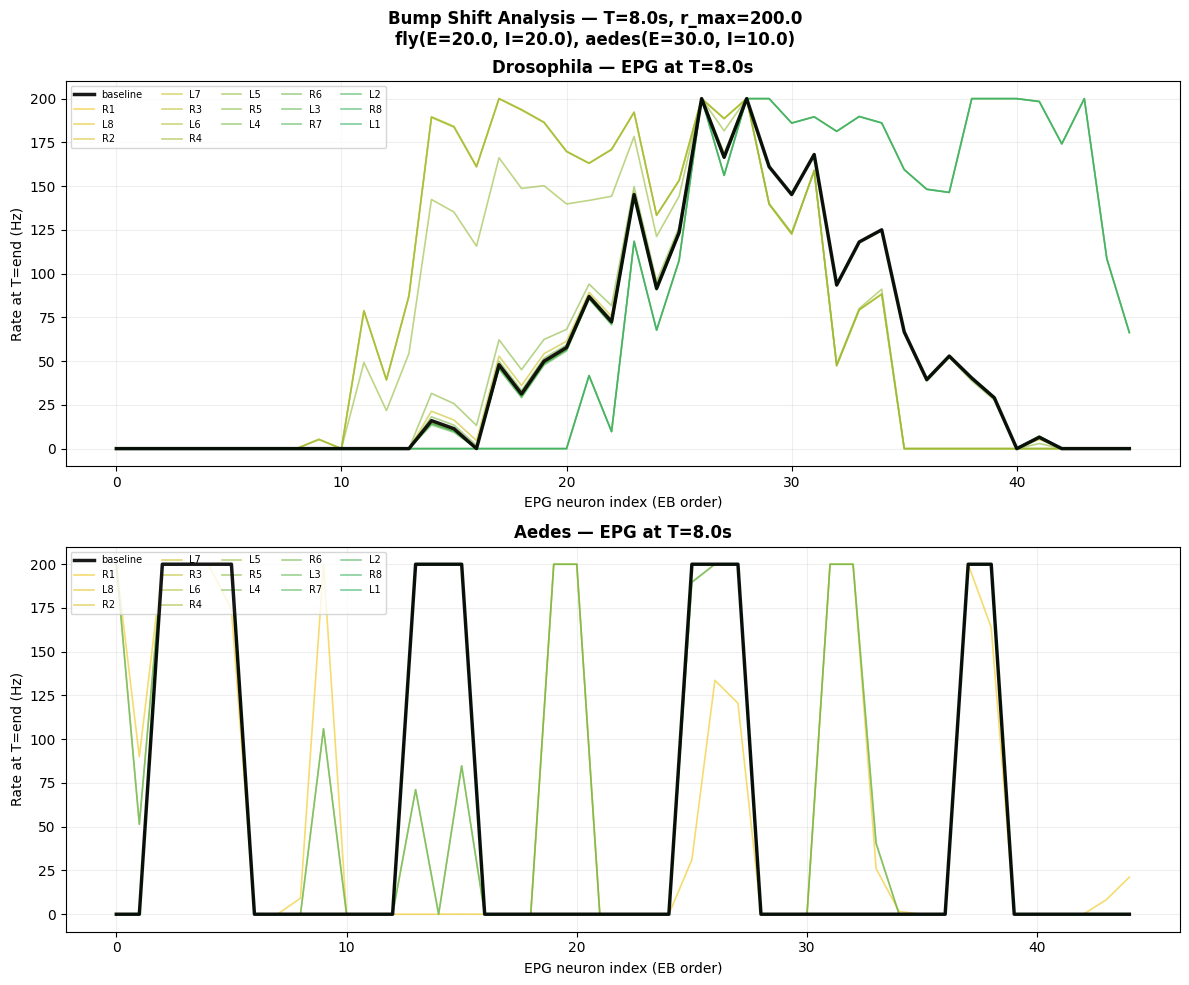

In [9]:
# EPG profiles at T=end: baseline vs each perturbation
fig, axes = plt.subplots(2, 1, figsize=(12, 10))
for ax, (sweep, name) in zip(axes, [
    (sweep_fly, 'Drosophila'), (sweep_aedes, 'Aedes'),
]):
    plot_epg_profiles(sweep, EB_RING_ORDER, CONFIG, name, ax=ax)

plt.suptitle(
    f'Bump Shift Analysis — T={CONFIG["T"]}s, r_max={CONFIG["r_max"]}\n'
    f'fly(E={CONFIG["gain_epg_fly"]}, I={CONFIG["gain_d7_fly"]}), '
    f'aedes(E={CONFIG["gain_epg_aedes"]}, I={CONFIG["gain_d7_aedes"]})',
    fontweight='bold')
plt.tight_layout()
plt.show()
